In [5]:
using Plots
using LinearAlgebra
using ImageFiltering
using Statistics
using DSP
using GR

In [44]:
# Define parameters
nx = 100
ny=nx
nz=nx
v = 1.0

# Compute time step and spatial step
xs = range(0, stop=10, length=nx)
h =diff(xs)[1]
C = 1 / 4
dt = 0.1

# Generate time array
ts = range(0,stop=10,length=200)
#dt=diff(ts)[1]
nt = length(ts)

mid=Int(nx/2)

50

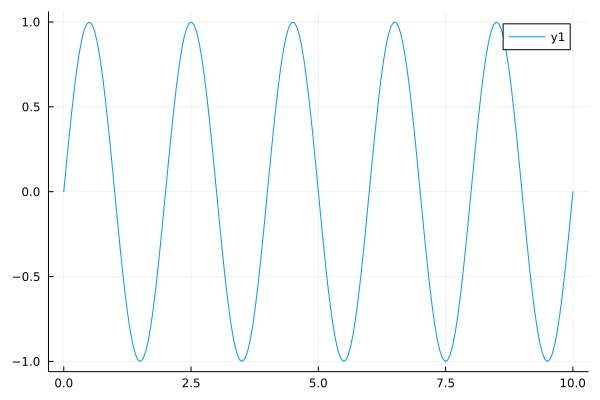

In [45]:
src1=1*sin.(2π*100*ts)
Plots.plot(ts,src1)

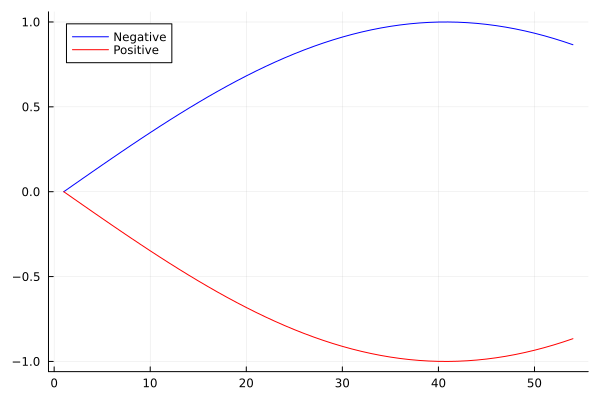

In [46]:
#y = sin.(repeat(xs',nt).-ts)
xs1=range(0,stop=10,length=54)
L=10-2.5
λ=4*L
ν=v/λ
y = sin.((2*π/λ)*repeat(xs1',nt)'.-2*π*ν*ts')
# Find indices for positive and negative values
idx_neg = findall(x -> x < 0, y)
idx_pos =findall(>(0), y)

# Create copies and modify
y1 = copy(y)
y2 = -(copy(y));
#y1[idx_neg].= 0; # Set negative values to zero (0.0 for clarity)
#y2[idx_pos].= 0; # Set positive values to zero

# Plot the results
Plots.plot(y1[:,1], label="Negative",color="blue")  # Add label for clarity
Plots.plot!(y2[:,1], label="Positive", color="red")  # Plot on same figure and add label
#plot!(y1[:,1]-y2[:,1])

#legend()  # Display legend

In [47]:
X, Y ,Z= meshgrid(xs,xs,xs);

In [48]:
pos1 = zeros(nx, ny, nz);
pos2 = copy(pos1)
neg = zeros(nx, ny, nz);
mid=Int(nx/2)
pos1[mid-2,mid-5:mid+7,mid,1].=1;
pos2[mid-42:mid-2,mid+8,mid,1].=1;


neg[mid+2,mid-5:mid+8,mid,1].=1;
neg[mid+2:mid+42,mid+8,mid,1].=1;

In [49]:
idx=findall(>(0),pos1);
idx1=findall(>(0),pos2);
idx2=findall(>(0),neg);

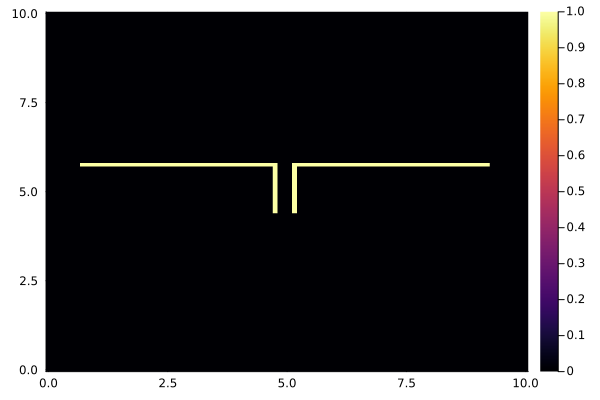

In [51]:
Plots.heatmap(xs,xs,(neg+pos1+pos2)[:,:,mid]')
#heatmap()
#heatmap!(neg[:,:,mid,1])

In [38]:
function neumann(a)
    a[1,:,:] = a[2,:,:]; a[end,:,:] = a[end-1,:,:]
    a[:,1,:] = a[:,2,:]; a[:,end,:] = a[:,end-1,:]
    a[:,:,1] = a[:,:,2]; a[:,:,end] = a[:,:,end-1]
    return a
end

neumann (generic function with 1 method)

In [39]:


# Generate kernel
function generate_kernel(n::Int)
    kernel = zeros(Float64, n, n, n)
    
    kernel[1:3, 2, 2] .= 1/6
    kernel[2, 1:3, 2] .= 1/6
    kernel[2, 2, 1:3] .= 1/6
    kernel[2, 2, 2] = 0.0
    return kernel
end

kern = generate_kernel(3);




### Falta mapear

In [36]:
err = []
iters = 2
grid=zeros(nx,ny,nz,nt)
grid1=zeros(nx,ny,nz)
grid2=copy(grid1)
########################
grid[Int(nx/2),Int(nx/2),Int(nx/2),1]=1

#grid1[idx].=(y1[1:13,1];)
#grid1[idx1].=reverse(y1[14:end,1];)
#grid1[idx2].=y2[:,1];
#grid[:,:,:,1]=grid1;




1

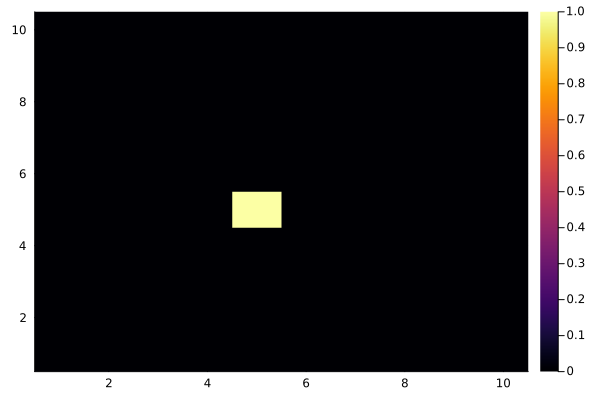

In [37]:
Plots.heatmap(grid[:,:,mid,1]')

In [40]:
function hjhj(grid,nx,ny,nz,nt,it)
    grid_updated=zeros(nx,ny,nz)
    dummy=copy(grid_updated)
    iters=it
    for tt in 1:nt
        for i in 1:iters
            # Update grid using convolution
            grid_updated =imfilter(grid[:,:,:,tt], kern)
                
            # Boundary conditions (Neumann)
            grid_updated = neumann(grid_updated)
            dummy 
            #dummy[idx].=y1[1:13,tt]
            #dummy[idx1].=reverse(y1[14:end,tt])
            #dummy[idx2].=y2[:,tt]
                
            # Boundary conditions (Dirichlet)
            grid_updated[idx].=dummy[idx]
            grid_updated[idx1].=dummy[idx1]
            grid_updated[idx2].=dummy[idx2]
                # Compute error between consecutive arrays
            #push!(err, mean((grid[:,:,:,tt] - grid_updated).^2))
            grid[:,:,:,tt] .= grid_updated
        end
    end
    return grid
end

hjhj (generic function with 1 method)

In [41]:
@time grid2=hjhj(grid,nx,ny,nz,nt,2);

LoadError: UndefVarError: idx not defined

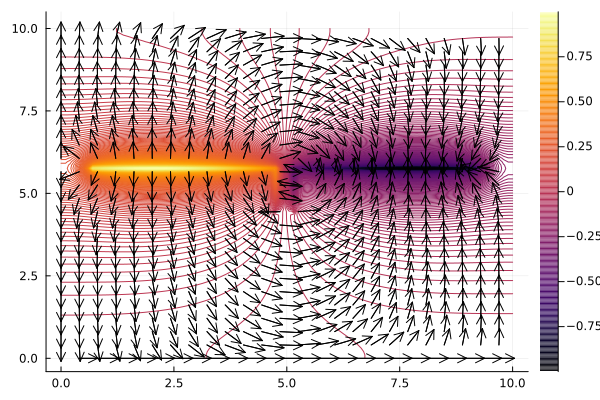

In [60]:
arr=range(1,nx,step=4)
Plots.contour(xs,xs,grid2[:,:,mid,1]',levels=300)
EE=Ef(grid2[:,:,:,1]);
Plots.quiver!(X[arr,arr,mid],Y[arr,arr,mid],quiver=(EE[1][arr,arr,mid], EE[2][arr,arr,mid]).*0.5,color="black")

In [ ]:
anim2d=@animate for i in 1:10:nt;
    Plots.contour(xs,xs,grid2[:,:,mid,i]',c=:bwr,levels=40)
    #EE=Ef(grid2[:,:,:,i]);
    #Plots.quiver!(X[arr,arr,mid],Y[arr,arr,mid],quiver=(EE[1][arr,arr,mid], EE[2][arr,arr,mid]).*0.5,color="black")
end;
gif(anim2d,"test4.gif",fps=24)

[ Info: Saved animation to C:\Users\Arif\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Files\Escuela\Carrera\4to Semestre\Electrodinamica\proyectos\Antenna\test2.gif


Plots.AnimatedGif("C:\\Users\\Arif\\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\\Files\\Escuela\\Carrera\\4to Semestre\\Electrodinamica\\proyectos\\Antenna\\test2.gif")
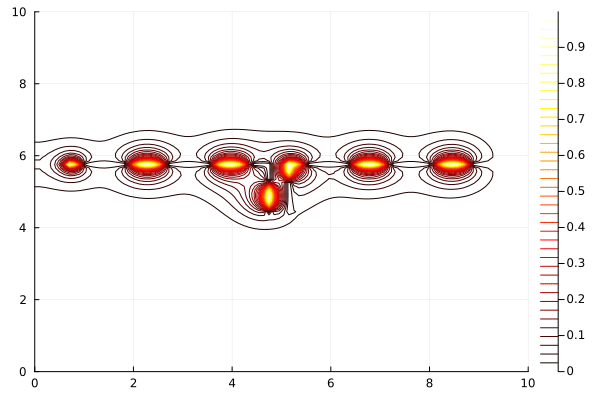

In [372]:
anim2d=@animate for i in 1:10:nt;
    f1=Figure()
    Axis(f1[1, 1])
    arr=range(1,nx,step=4)
    Plots.contour(xs,xs,grid[:,:,mid,i]',levels=40,colormap=:hot)
    #Colorbar(f1[1,2],co)
    #col=sqrt.(vec(copy(Ex[arr,arr,mid]).^2)+vec(copy(Ey[arr,arr,mid]).^2));
    #arrows!(xs[arr], xs[arr], Ex[arr,arr,mid], Ey[arr,arr,mid], arrowsize = 10, lengthscale = 0.3,arrowcolor=col,linecolor=col)
    #display(f1)
    #return display(f1)
end;
gif(anim2d,"test2.gif",fps=24)


In [34]:
function Ef(grid2)
    Ex=zeros(nx,ny,nz)
    Ey=copy(Ex)
    Ez=copy(Ex)
    Ex[2:100,:,:].=-diff(grid2[:,:,:],dims=1)/h;
    Ey[:,2:100,:].=-diff(grid2[:,:,:],dims=2)/h;
    Ez[:,:,2:100].=-diff(grid2[:,:,:],dims=3)/h;
    
    
    EM=sqrt.(Ex.^2+Ey.^2+Ez.^2);
    E=[Ex./EM,Ey./EM,Ez./EM];
    return E
end

Ef (generic function with 1 method)

In [598]:
#Plots.contour(grid[:,:,mid,2]',cmap=:hot)
#GR.arrows!(xs[arr], xs[arr], Ex[arr,arr,mid], Ey[arr,arr,mid], arrowsize = 10,
   # lengthscale = 0.3)

In [639]:
arr

1:2:99

In [667]:
size(grid2[:,:,mid,1])

(100, 100)

In [737]:
Ef(grid2[:,:,:,10]);

3-element Vector{Array{Float64, 3}}:
 [NaN NaN … 0.0 NaN; NaN NaN … -0.0 NaN; … ; 1.0 1.0 … 0.021407600207640664 1.0; NaN NaN … -0.0 NaN;;; NaN NaN … 0.0 NaN; NaN NaN … -0.0 NaN; … ; 1.0 1.0 … 0.021407600207640664 1.0; NaN NaN … -0.0 NaN;;; 0.0 0.0 … 0.0 0.0; -0.0 -0.0 … -0.0 -0.0; … ; 0.034011406622043605 0.034011406622043605 … 0.014243532665129543 0.02258160950522324; -0.0 -0.0 … -0.0 -0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; -0.0 -0.0 … -0.0 -0.0; … ; 0.008880336684837857 0.008880336684837857 … 0.00951431722865414 0.010493794642796827; -0.0 -0.0 … -0.0 -0.0;;; 0.0 0.0 … 0.0 0.0; -0.0 -0.0 … -0.0 -0.0; … ; 0.01786139344555408 0.01786139344555408 … 0.011531592083255411 0.014242131443574864; -0.0 -0.0 … -0.0 -0.0;;; NaN NaN … 0.0 NaN; NaN NaN … -0.0 NaN; … ; 1.0 1.0 … 0.019645541118256723 1.0; NaN NaN … -0.0 NaN]
 [NaN NaN … 1.0 NaN; NaN NaN … 1.0 NaN; … ; 0.0 -0.0 … 0.999770831067475 -0.0; NaN NaN … 1.0 NaN;;; NaN NaN … 1.0 NaN; NaN NaN … 1.0 NaN; … ; 0.0 -0.0 … 0.999770831067475 -0.0; NaN NaN

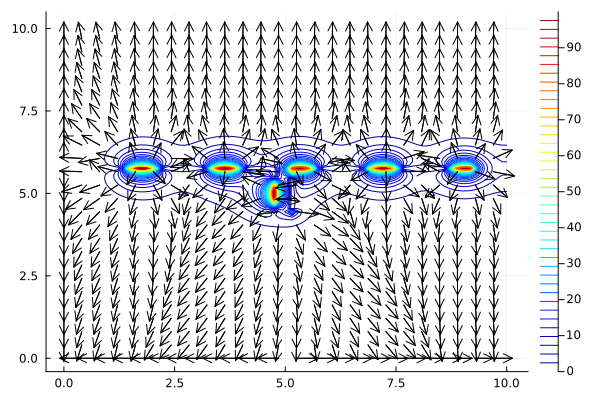

In [739]:
Plots.contour(xs,xs,grid2[:,:,mid,10]',c=:jet,levels=40)
EE=Ef(grid2[:,:,:,10]);
Plots.quiver!(X[arr,arr,mid],Y[arr,arr,mid],quiver=(EE[1][arr,arr,mid], EE[2][arr,arr,mid]).*0.5,color="black")

In [676]:
using GR
x = range(-2, 2,length= 210)
y = x

z = X.*exp.(-X.^2 - Y.^2)
#pp=GR.contour(x, y, z,levels=100)
u, v = GR.gradient(x, y, z)
p=GR.quiver(x, y, u, v)
display(p)

Arrays have incorrect length or dimension.


nothing

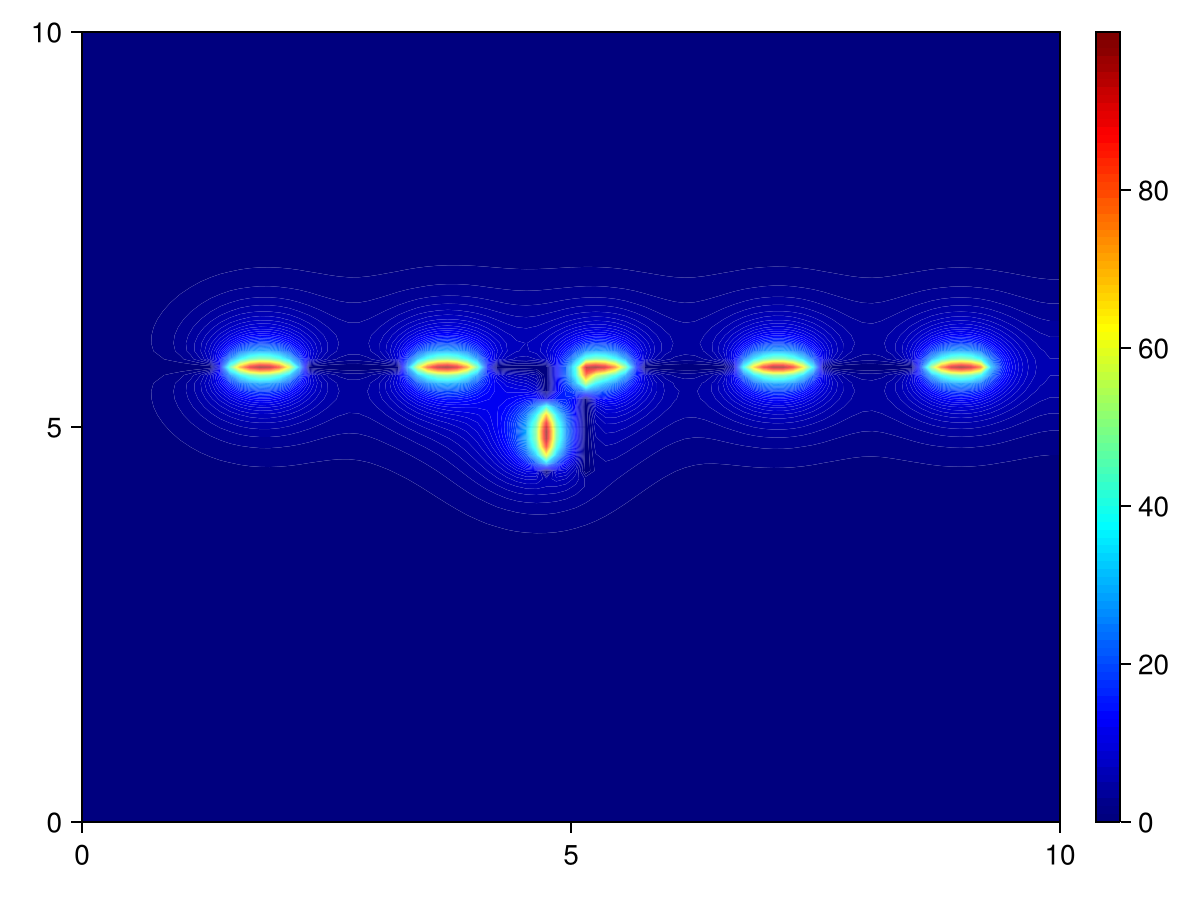

CairoMakie.Screen{IMAGE}


In [701]:
using CairoMakie

#f2 = Figure(resolution = (800, 800))
#Axis(f2[2, 2], backgroundcolor = "")

#strength=vec(sqrt.(u[:,:,5].^2+v[:,:,5].^2))
f1=Figure()
Axis(f1[1, 1])
arr=range(1,nx,step=4)
co=CairoMakie.contourf!(xs,xs,grid2[:,:,mid,1],levels=100,colormap=:jet)
Colorbar(f1[1,2],co)
col=sqrt.(vec(copy(Ex[arr,arr,mid]).^2)+vec(copy(Ey[arr,arr,mid]).^2));
#streamplot!(xs[arr], xs[arr], E[1][arr,arr,mid], E[2][arr,arr,mid], arrowsize = 5, lengthscale = 0.4,color="black")
display(f1)
#f = Figure(resolution = (800, 800))
#Axis(f[1, 1], backgroundcolor = "black")
#using GR
#XX=
#GR.quiver(X[:,:,mid],Y[:,:,mid],X[:,:,mid],Y[:,:,mid])
#Plots.quiver(X[:,:,mid,1],Y[:,:,mid,1],quiver=(Ex[:,:,mid,1],Ey[:,:,mid,1]))

In [717]:
using CairoMakie


struct FitzhughNagumo{T}
    ϵ::T
    s::T
    γ::T
    β::T
end

P = FitzhughNagumo(0.1, 0.0, 1.5, 0.8)

ff(x, P::FitzhughNagumo) = Point2f(
    (x[1]-x[2]-x[1]^3+P.s)/P.ϵ,
    P.γ*x[1]-x[2] + P.β
)

f4(x) = ff(x, P)

fig, ax, pl = streamplot(ff, -1.5..1.5, -1.5..1.5, colormap = :magma)
# you can also pass a function to `color`, to either return a number or color value
Cairomackie.streamplot(fig[1,2], f4, -1.5 .. 1.5, -1.5 .. 1.5, color=(p)-> RGBAf(p..., 0.0, 1))
fig

LoadError: UndefVarError: streamplot not defined

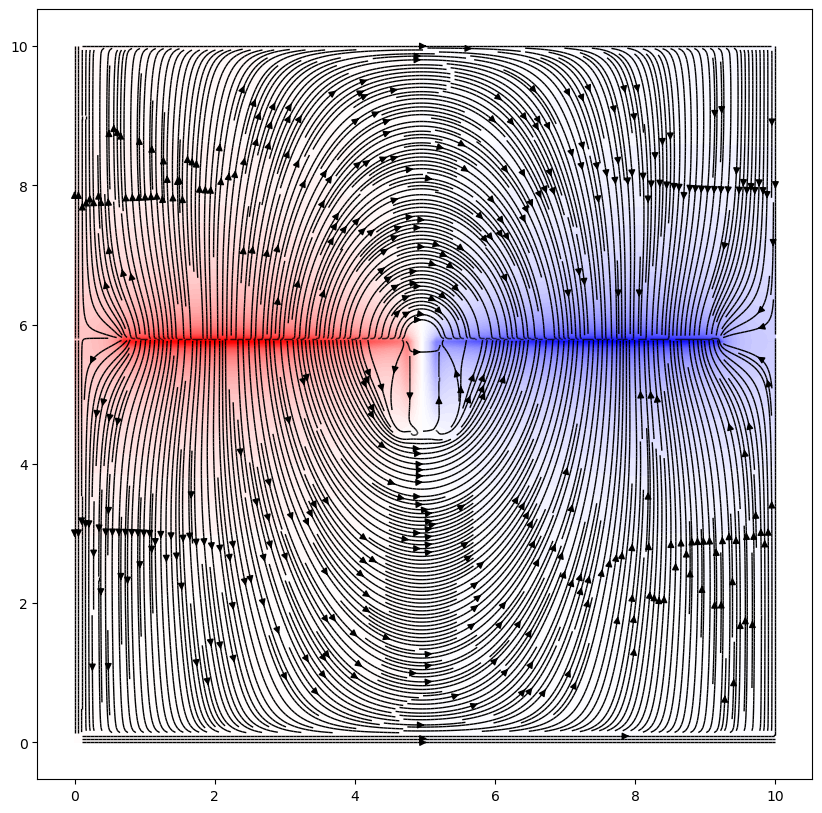

PyObject <matplotlib.streamplot.StreamplotSet object at 0x000001A9EC55EC80>

In [65]:
using PyCall, PyPlot
fig = PyPlot.figure(figsize=(10,10))
ax = fig.add_subplot(111)
plt.contourf(X[:,:,mid],Y[:,:,mid],grid2[:,:,mid,1],levels=100,cmap="bwr")
#cl=sqrt.(u.^2+v.^2+w.^2)
plt.streamplot(X[:,:,mid]',Y[:,:,mid]',EE[1][:,:,mid]',EE[2][:,:,mid]',color="black",density=6,linewidth=1)

In [93]:
#f2 = Figure(resolution = (800, 800))
#Axis(f2[2, 2], backgroundcolor = "black")
GR.quiver(xs,xs,X[:,:,mid],Y[:,:,mid])

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Arif\.julia\packages\Makie\fyNiH\src\scenes.jl:220


[ Info: Saved animation to C:\Users\Arif\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\Files\Escuela\Carrera\4to Semestre\Electrodinamica\proyectos\Onda electroMag\hola.gif


Plots.AnimatedGif("C:\\Users\\Arif\\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\\Files\\Escuela\\Carrera\\4to Semestre\\Electrodinamica\\proyectos\\Onda electroMag\\hola.gif")
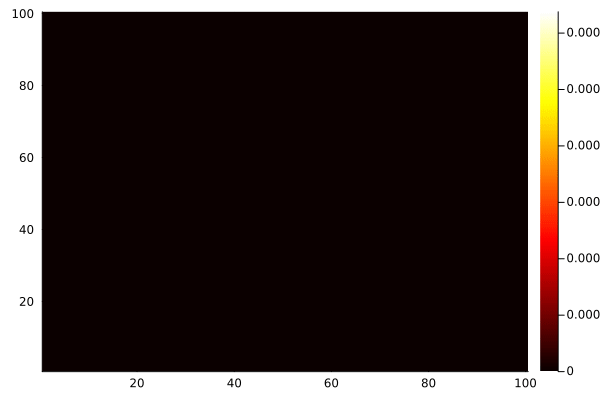

In [92]:
anim2d=@animate for i in 1:2:nt;
    Plots.heatmap(U[:,:,Int(nx/2),i],levels=[0,dt^2],c=:hot,clims=(0, dt^2))
end;
gif(anim2d,"hola.gif",fps=24)